# 02 · Cleaning and leakage-free feature engineering

Cleaning and feature engineering are separated by whether they learn anything from the data, so that
validation rows never influence what the model is trained on:

| Step | Where | Learns from data? |
|---|---|---|
| Deterministic plausibility rules | `car_price.data.clean` | no, fixed constants in `configs/default.yaml` |
| km/year quantile, top brands, `Engine` imputer, winsorisation bounds | `FeatureBuilder.fit` | yes, **training folds only** |
| Encoding, scaling | `ColumnTransformer` inside the pipeline | yes, training folds only |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from car_price.config import load_config, resolve
from car_price.data import TARGET, clean, load_dataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
cfg = load_config()
FIG = resolve(cfg, "figures"); FIG.mkdir(parents=True, exist_ok=True)

from car_price.features import FeatureBuilder, NUMERIC, LOW_CARD, HIGH_CARD
raw, source = load_dataset(cfg)
c = cfg["cleaning"]

## Cleaning funnel

In [2]:
steps = []
df = raw.copy()
for col in df.select_dtypes(include=["object", "string"]): df[col] = df[col].str.strip()
def log(name, frame): steps.append((name, len(frame)))
log("raw listings", df)
df = df.drop_duplicates();                                           log("drop exact duplicates", df)
df = df[df.MatriculationYear >= c["min_year"]];                      log(f"year >= {c['min_year']}", df)
df = df[df.km <= c["max_km"]];                                       log("km missing or implausible (>= 1e9)", df)
age = (c["reference_year"] - df.MatriculationYear).clip(lower=1)
df = df[df.km <= age * c["max_km_per_year"]];                        log(f"km/year <= {c['max_km_per_year']:,}", df)
df = df[df.cv.between(*c["cv_range"])];                              log(f"power in {c['cv_range']} cv", df)
final = clean(raw, cfg);                                             log("other rules + required fields (final)", final)
funnel = pd.DataFrame(steps, columns=["step", "rows"]).assign(removed=lambda d: -d.rows.diff().fillna(0).astype(int))
funnel

,step,rows,removed
0,raw listings,178248,0
1,drop exact duplicates,131845,46403
2,year >= 1950,131829,16
3,km missing or implausible (>= 1e9),110478,21351
4,"km/year <= 35,000",109441,1037
5,"power in [8, 800] cv",101882,7559
6,other rules + required fields (final),101188,694


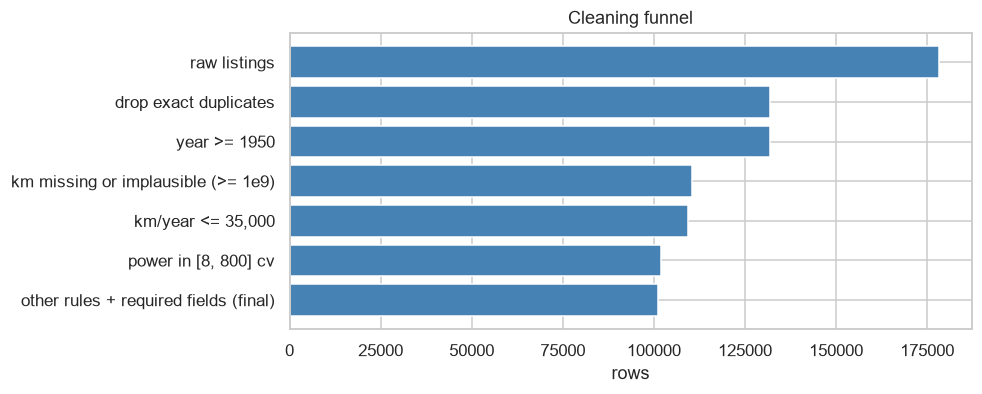

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(funnel.step[::-1], funnel.rows[::-1], color="steelblue"); ax.set(xlabel="rows", title="Cleaning funnel")
plt.show()

## Car age
Mileage per year is `km / car_age`. A car registered in the reference year has `car_age = 0`, which would give
`inf`/`NaN` and a zero mileage cap. The age is therefore clipped to at least 1. This snapshot contains no such listing
(see below), so the clipping has no effect on these data.

In [4]:
print("latest registration year in raw data:", raw.MatriculationYear.max())
print("listings with car_age == 0:", int(((c["reference_year"] - raw.MatriculationYear) == 0).sum()))

latest registration year in raw data: 2018
listings with car_age == 0: 0


## Feature builder
`FeatureBuilder` turns the cleaned frame into numeric, low-cardinality and high-cardinality groups. It is fitted only on the rows it is given, which the tests verify.

In [5]:
X = final.drop(columns=TARGET)
fb = FeatureBuilder(reference_year=c["reference_year"]).fit(X)
feats = fb.transform(X)
print("learned from data ->", f"km/year p99 = {fb.km_per_year_q99_:,.0f}",
      f"| {len(fb.top_brands_)} top brands | winsorised to [p0.1, p99.9]")
pd.DataFrame({"group": ["numeric"]*len(NUMERIC) + ["low-card"]*len(LOW_CARD) + ["high-card"]*len(HIGH_CARD),
              "feature": NUMERIC + LOW_CARD + HIGH_CARD}).groupby("group").feature.apply(", ".join).to_frame()

learned from data -> km/year p99 = 30,208 | 30 top brands | winsorised to [p0.1, p99.9]


,feature
group,
high-card,"Brand, Model, province"
low-card,"FuelType, gearboxType, Airbag, EmissionClass, ..."
numeric,"km, cv, car_age, avg_km_per_year, km_vs_expect..."


In [6]:
feats.head()

,km,cv,car_age,avg_km_per_year,km_vs_expected,Engine,Seats,ConsumeFuel,Emissions,specialModel,FuelType,gearboxType,Airbag,EmissionClass,AirConditioning,NumberDoors,brandSegment,Brand,Model,province
0,82914.0,85.0,6.0,13819.000000,0.457458,1995.0,5.0,4.1,109.0,0.0,Diesel,Cambio automatico,Unknown,Unknown,Unknown,Unknown,Luxury,BMW,Serie 1,Modena
1,161038.0,75.0,13.0,12387.538462,0.410071,1595.0,5.0,7.2,176.0,0.0,Benzina,Cambio manuale,Unknown,Unknown,Unknown,Unknown,Ordinary,VOLKSWAGEN,Golf,Modena
2,114830.0,80.0,5.0,22966.000000,0.760256,1461.0,5.0,3.8,98.0,1.0,Diesel,Cambio manuale,Unknown,Unknown,Unknown,Unknown,Luxury,MERCEDES-BENZ,Classe A,Modena
3,61700.0,183.0,3.0,20566.666667,0.680830,2993.0,5.0,5.9,156.0,1.0,Diesel,Cambio automatico,Unknown,Unknown,Unknown,Unknown,Luxury,BMW,X5,Padova
4,25790.0,190.0,5.0,5158.000000,0.170748,2993.0,5.0,6.2,162.0,1.0,Diesel,Cambio automatico,Unknown,Unknown,Unknown,Unknown,Luxury,BMW,X5,Padova


## Encoding by model family
| Family | numeric | low-cardinality categoricals | `Brand`, `Model`, `province` |
|---|---|---|---|
| Ridge / ElasticNet / Poly-Ridge | median impute + standardise (+ degree-2 terms on numerics only) | one-hot | cross-fitted **target encoding** + standardise |
| Random forest / XGBoost / LightGBM | passthrough (native `NaN`) | ordinal | cross-fitted target encoding |
| CatBoost | passthrough | native categorical | native categorical (ordered target statistics) |

The target is always `log1p(price)` via `TransformedTargetRegressor`; predictions are returned in euros.